In [12]:
%pip install matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger directement le fichier local
df_raw = None
for enc in ['utf-8', 'latin-1', 'cp1252']:
    for sep in [',', ';', '\t']:
        try:
            tmp = pd.read_csv('data.csv', encoding=enc, sep=sep, on_bad_lines='skip')
            if len(tmp.columns) > 3:
                df_raw = tmp
                print(f'OK encodage={enc}, separateur="{sep}"')
                break
        except:
            continue
    if df_raw is not None:
        break

print(f'Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes')
print(f'Colonnes : {list(df_raw.columns)}')
df_raw.head(10)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
OK encodage=latin-1, separateur=";"
Dimensions : 1267 lignes x 24 colonnes
Colonnes : ['Group', 'Sex', 'Age', 'Patients number per hour', 'Arrival mode', 'Injury', 'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'KTAS_RN', 'Diagnosis in ED', 'Disposition', 'KTAS_expert', 'Error_group', 'Length of stay_min', 'KTAS duration_min', 'mistriage']



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1
5,2,1,54,6,4,1,fever,1,1,3,...,38.1,98,3,"Fever, unspecified",2,4,1,9246,"2,00",1
6,2,2,49,11,3,1,With chest discomfort,1,1,3,...,36.2,98,2,"Angina pectoris, unspecified",1,3,2,400,"3,00",1
7,1,2,78,14,3,1,"pain, chest",1,1,3,...,36,NaN,2,Acute coronary syndrome,1,3,2,247,"10,23",1
8,1,2,32,10,3,1,LBP - Low back pain,1,1,3,...,36.6,NaN,4,Herniated disc disease of lumbar spine with ra...,1,5,4,59,"3,23",1
9,2,1,38,6,3,1,"Eczema, Eyelid",1,1,3,...,36.3,97,4,Ocular pain,1,5,4,185,"4,00",1


In [13]:
print('=== VALEURS MANQUANTES ===')
missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Manquantes': missing, 'Pct %': pct})[missing > 0])
print('\n=== STATISTIQUES ===')
df_raw.describe()

=== VALEURS MANQUANTES ===
                 Manquantes  Pct %
Saturation              688  54.30
Diagnosis in ED           2   0.16

=== STATISTIQUES ===


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min,mistriage
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,3.335438,1.609313,3.265983,0.558011,11016.102605,0.250197
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,0.885391,1.157983,0.885803,1.571489,80446.092065,0.628250
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,1.000000,3.000000,0.000000,133.000000,0.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,0.000000,274.000000,0.000000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,4.000000,0.000000,606.500000,0.000000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,5.000000,7.000000,5.000000,9.000000,709510.000000,2.000000


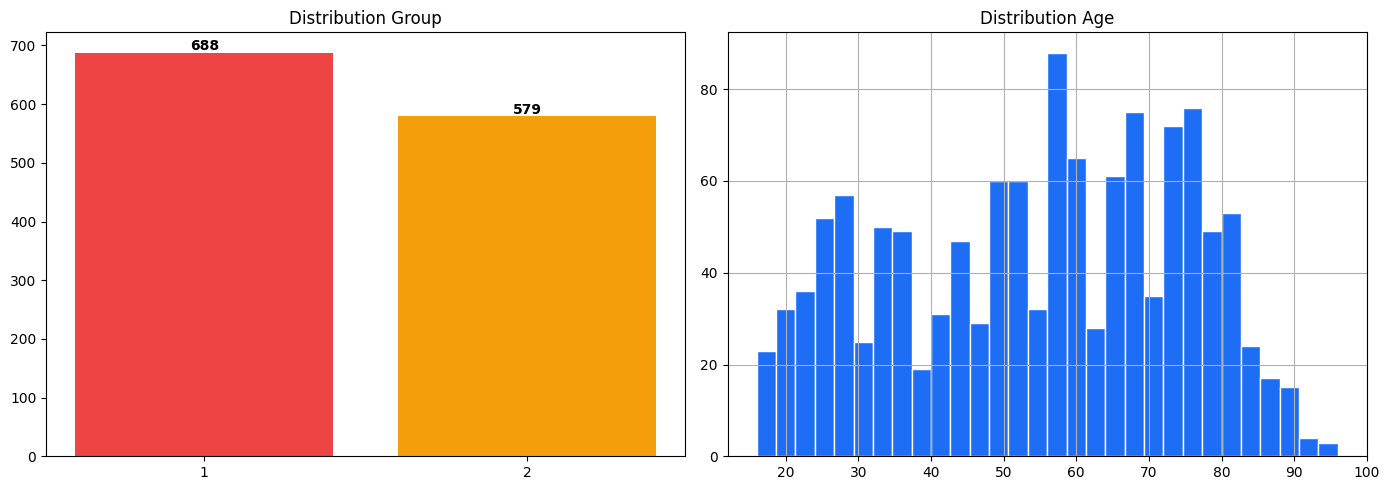

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_raw['Group'].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color=['#ef4444','#f59e0b','#3b82f6'])
axes[0].set_title('Distribution Group')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
df_raw['Age'].dropna().hist(bins=30, ax=axes[1], color='#1D6EF5', edgecolor='white')
axes[1].set_title("Distribution Age")
plt.tight_layout()
plt.show()

In [15]:
# CELLULE 5 : NETTOYAGE COMPLET
df = df_raw.copy()
print(f'Avant : {len(df)} lignes')

# 1. Supprimer doublons
n = len(df)
df = df.drop_duplicates()
print(f'[1] Doublons supprimes : {n - len(df)}')

# 2. Renommer colonnes
df.columns = [c.strip().replace(' ','_').lower() for c in df.columns]
print(f'[2] Colonnes : {list(df.columns)}')

# 3. Nettoyer Age
df['age'] = pd.to_numeric(df['age'], errors='coerce')
med = df['age'].median()
df = df[(df['age'].isna()) | ((df['age'] >= 0) & (df['age'] <= 120))]
df['age'] = df['age'].fillna(med)
print(f'[3] Age nettoye - mediane={med:.0f}')

# 4. Nettoyer colonnes numeriques
for col in ['sex','patients_number_per_hour','arrival_mode','injury',
            'mental','pain','nrs_pain','ktas_rn','disposition','ktas_expert']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].mode()[0])
        df[col] = df[col].astype(int)
print('[4] Colonnes numeriques nettoyees')

# 5. Supprimer colonnes inutiles
cols_suppr = ['error_group','saturation','diagnosis_in_ed','mistriage',
              'length_of_stay_min','ktas_duration_min','sbp','dbp','hr','rr','bt']
cols_suppr = [c for c in cols_suppr if c in df.columns]
df = df.drop(columns=cols_suppr)
print(f'[5] Colonnes supprimees : {cols_suppr}')

# 6. LABEL : KTAS_RN (5 niveaux) → P1/P2/P3
def ktas_to_priorite(k):
    if k <= 2:   return 'P1'
    elif k == 3: return 'P2'
    else:        return 'P3'

df['priorite'] = df['ktas_rn'].apply(ktas_to_priorite)

print(f'\nDistribution KTAS_RN :')
print(df['ktas_rn'].value_counts().sort_index())
print(f'\nApres nettoyage : {len(df)} lignes')
print(f'P1={len(df[df["priorite"]=="P1"])} | P2={len(df[df["priorite"]=="P2"])} | P3={len(df[df["priorite"]=="P3"])}')
df.head()

Avant : 1267 lignes
[1] Doublons supprimes : 0
[2] Colonnes : ['group', 'sex', 'age', 'patients_number_per_hour', 'arrival_mode', 'injury', 'chief_complain', 'mental', 'pain', 'nrs_pain', 'sbp', 'dbp', 'hr', 'rr', 'bt', 'saturation', 'ktas_rn', 'diagnosis_in_ed', 'disposition', 'ktas_expert', 'error_group', 'length_of_stay_min', 'ktas_duration_min', 'mistriage']
[3] Age nettoye - mediane=57
[4] Colonnes numeriques nettoyees
[5] Colonnes supprimees : ['error_group', 'saturation', 'diagnosis_in_ed', 'mistriage', 'length_of_stay_min', 'ktas_duration_min', 'sbp', 'dbp', 'hr', 'rr', 'bt']

Distribution KTAS_RN :
ktas_rn
1     18
2    214
3    447
4    501
5     87
Name: count, dtype: int64

Apres nettoyage : 1267 lignes
P1=232 | P2=447 | P3=588


C:\Users\MSI\AppData\Local\Temp\ipykernel_2360\1782895077.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['age'] = pd.to_numeric(df['age'], errors='coerce')
C:\Users\MSI\AppData\Local\Temp\ipykernel_2360\1782895077.py:18: FutureWarni

,group,sex,age,patients_number_per_hour,arrival_mode,injury,chief_complain,mental,pain,nrs_pain,ktas_rn,disposition,ktas_expert,priorite
0,2,2,71,3,3,2,right ocular pain,1,1,2,2,1,4,P1
1,1,1,56,12,3,2,right forearm burn,1,1,2,4,1,5,P3
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,4,2,5,P3
3,1,2,71,8,1,1,ascites tapping,1,1,3,4,1,5,P3
4,1,2,58,4,3,1,"distension, abd",1,1,3,4,1,5,P3


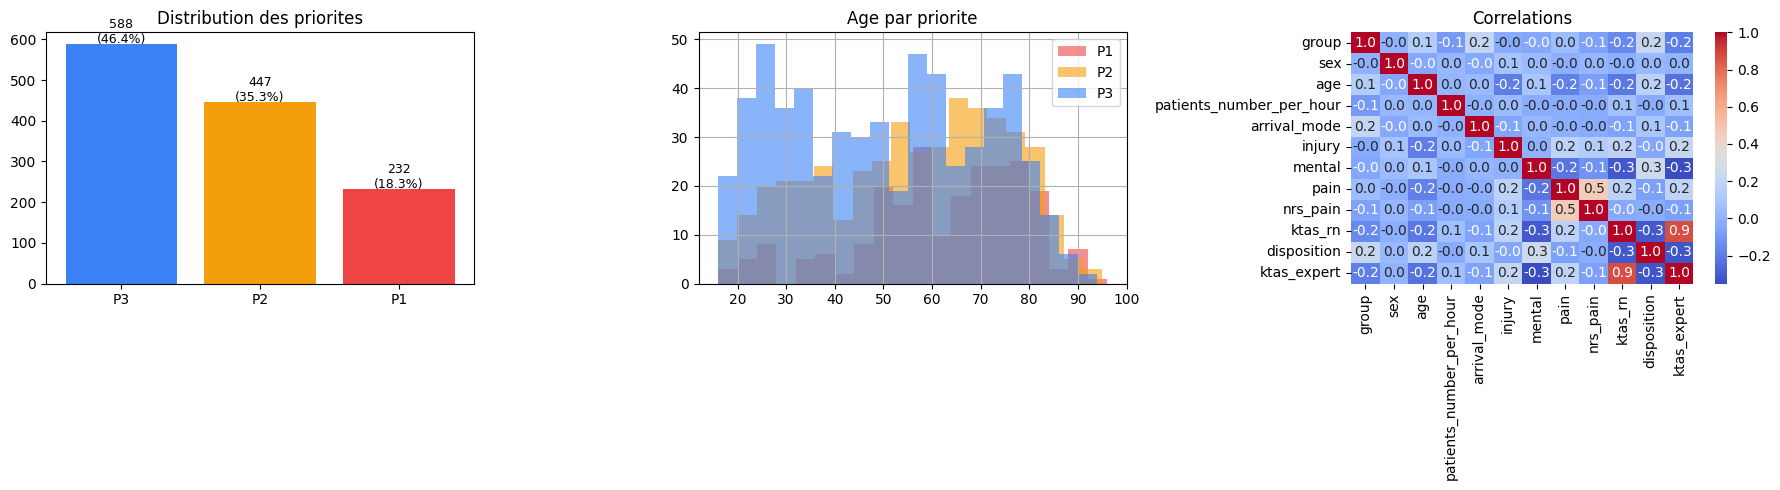

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_p = {'P1':'#ef4444','P2':'#f59e0b','P3':'#3b82f6'}

# Distribution priorités
counts = df['priorite'].value_counts()
axes[0].bar(counts.index, counts.values, color=[colors_p[p] for p in counts.index])
axes[0].set_title('Distribution des priorites')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+2, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Age par priorité
for p, c in colors_p.items():
    df[df['priorite']==p]['age'].hist(bins=20, alpha=0.6, label=p, color=c, ax=axes[1])
axes[1].set_title('Age par priorite')
axes[1].legend()

# Heatmap corrélations
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), ax=axes[2], cmap='coolwarm', annot=True, fmt='.1f')
axes[2].set_title('Correlations')

plt.tight_layout()
plt.show()

In [18]:
df.to_csv('data_clean.csv', index=False, encoding='utf-8')
print(f'Lignes finales : {len(df)}')
print(f'Colonnes : {list(df.columns)}')
print(f'P1={len(df[df["priorite"]=="P1"])} | P2={len(df[df["priorite"]=="P2"])} | P3={len(df[df["priorite"]=="P3"])}')
print('data_clean.csv sauvegarde dans ai-Model/')

Lignes finales : 1267
Colonnes : ['group', 'sex', 'age', 'patients_number_per_hour', 'arrival_mode', 'injury', 'chief_complain', 'mental', 'pain', 'nrs_pain', 'ktas_rn', 'disposition', 'ktas_expert', 'priorite']
P1=232 | P2=447 | P3=588
data_clean.csv sauvegarde dans ai-Model/
